# Clinical Decision Support System via Parameter-Efficient Fine-Tuning of MedGemma

This notebook is a complete project notebook for:
- loading the **NCT-CRC-HE-100K** colorectal histology dataset
- training a **ViT baseline**
- evaluating the baseline with accuracy and a confusion matrix
- loading **MedGemma**
- converting the task into **multimodal instruction tuning**
- fine-tuning **MedGemma with QLoRA**
- testing generation-based tissue classification
- saving outputs for a final demo

## Recommended workflow
1. Run the **baseline** section first and save results.
2. Then run the **MedGemma inference** section to verify gated access.
3. Then run the **QLoRA fine-tuning** section on a small subset.
4. Scale up only after the small run works.

## Important
MedGemma is a **gated model** on Hugging Face. You must:
- request/accept access on the model page
- create a Hugging Face token
- add it to Colab secrets as `HF_TOKEN`

This notebook is designed for **Google Colab GPU runtime**.

> Improved version generated from your original notebook. The main MedGemma changes are in **Part C**: balanced training, augmentation, stronger LoRA settings, assistant-only loss masking, robust label parsing, and normalized confusion-matrix evaluation.

## 1. Install dependencies

In [ ]:
!pip install -q -U transformers datasets accelerate bitsandbytes peft trl torchvision gradio evaluate scikit-learn sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 164.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 165.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 161.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports and setup

In [ ]:
import os
import glob
from google.colab import drive

# Mount Google Drive at the beginning
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/MedGemma_Colorectal_Project_v2'
os.makedirs(DRIVE_PATH, exist_ok=True)

# --- FIX FOR BITSANDBYTES CUDA ERROR IN COLAB ---
os.environ["BNB_CUDA_VERSION"] = "124"
nvidia_libs = glob.glob('/usr/local/lib/python3.*/dist-packages/nvidia/*/lib')
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = os.environ.get('LD_LIBRARY_PATH', '') + ':' + ':'.join(nvidia_libs)
# ------------------------------------------------

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import evaluate

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

Mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 3. Verify GPU

In [ ]:
!nvidia-smi

Sun May  3 23:11:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             47W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 4. Hugging Face login for MedGemma

Run this before loading MedGemma. Make sure you already stored `HF_TOKEN` in Colab Secrets.

In [ ]:
from huggingface_hub import login
from google.colab import userdata

try:
    login(token=userdata.get("HF_TOKEN"))
    print("Hugging Face login successful.")
except Exception as e:
    print("Login failed.")
    print(e)
    print("Make sure HF_TOKEN exists in Colab secrets and that you accepted access to the MedGemma model.")

Hugging Face login successful.


## 5. Dataset setup

If `data/NCT-CRC-HE-100K` already exists, skip the download cell.

In [ ]:
# Uncomment only if the dataset is not already present.
# !wget -O NCT-CRC-HE-100K.zip https://zenodo.org/records/1214456/files/NCT-CRC-HE-100K.zip
# !unzip -q NCT-CRC-HE-100K.zip -d data/

--2026-05-03 23:11:06--  https://zenodo.org/records/1214456/files/NCT-CRC-HE-100K.zip
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 137.138.153.219, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11690284003 (11G) [application/octet-stream]
Saving to: ‘NCT-CRC-HE-100K.zip’

NCT-CRC-HE-100K.zip 100%[===================>]  10.89G  15.3MB/s    in 12m 14s 

2026-05-03 23:23:21 (15.2 MB/s) - ‘NCT-CRC-HE-100K.zip’ saved [11690284003/11690284003]



In [ ]:
!ls -lh data
!ls -lh data/NCT-CRC-HE-100K | head

total 4.0K
drwxr-xr-x 11 root root 4.0K Mar 19  2018 NCT-CRC-HE-100K
total 3.6M
drwxr-xr-x 2 root root 360K Mar 19  2018 ADI
drwxr-xr-x 2 root root 432K Mar 19  2018 BACK
drwxr-xr-x 2 root root 436K Mar 19  2018 DEB
drwxr-xr-x 2 root root 416K Mar 19  2018 LYM
drwxr-xr-x 2 root root 276K Mar 19  2018 MUC
drwxr-xr-x 2 root root 492K Mar 19  2018 MUS
drwxr-xr-x 2 root root 356K Mar 19  2018 NORM
drwxr-xr-x 2 root root 356K Mar 19  2018 STR
drwxr-xr-x 2 root root 496K Mar 19  2018 TUM


## 6. Load the NCT-CRC-HE-100K dataset

In [ ]:
raw_dataset = load_dataset(
    "imagefolder",
    data_dir="data/NCT-CRC-HE-100K"
)

# IMPORTANT: keep the validation split stratified so every tissue type is represented.
# Create an 80/10/10 train/validation/test split
train_temp_split = raw_dataset["train"].train_test_split(
    test_size=0.2, # 20% for temp (validation + test)
    seed=SEED,
    stratify_by_column="label",
)

temp_val_test_split = train_temp_split["test"].train_test_split(
    test_size=0.5, # 10% for validation, 10% for test
    seed=SEED,
    stratify_by_column="label",
)

dataset = {
    "train": train_temp_split["train"],
    "validation": temp_val_test_split["train"],
    "test": temp_val_test_split["test"], # This 'test' split will be used for final in-training evaluation
}
label_names = dataset["train"].features["label"].names

print(dataset)
print("Labels:", label_names)
print("Number of classes:", len(label_names))

# Show class distribution. A collapsed confusion matrix is often caused by imbalance or bad sampling.
from collections import Counter
import pandas as pd

train_counts = Counter(dataset["train"]["label"])
validation_counts = Counter(dataset["validation"]["label"])
test_counts = Counter(dataset["test"]["label"])
class_distribution = pd.DataFrame({
    "label_id": range(len(label_names)),
    "label": label_names,
    "train_count": [train_counts.get(i, 0) for i in range(len(label_names))],
    "validation_count": [validation_counts.get(i, 0) for i in range(len(label_names))],
    "test_count": [test_counts.get(i, 0) for i in range(len(label_names))],
})
display(class_distribution)


## 7. Visualize sample images

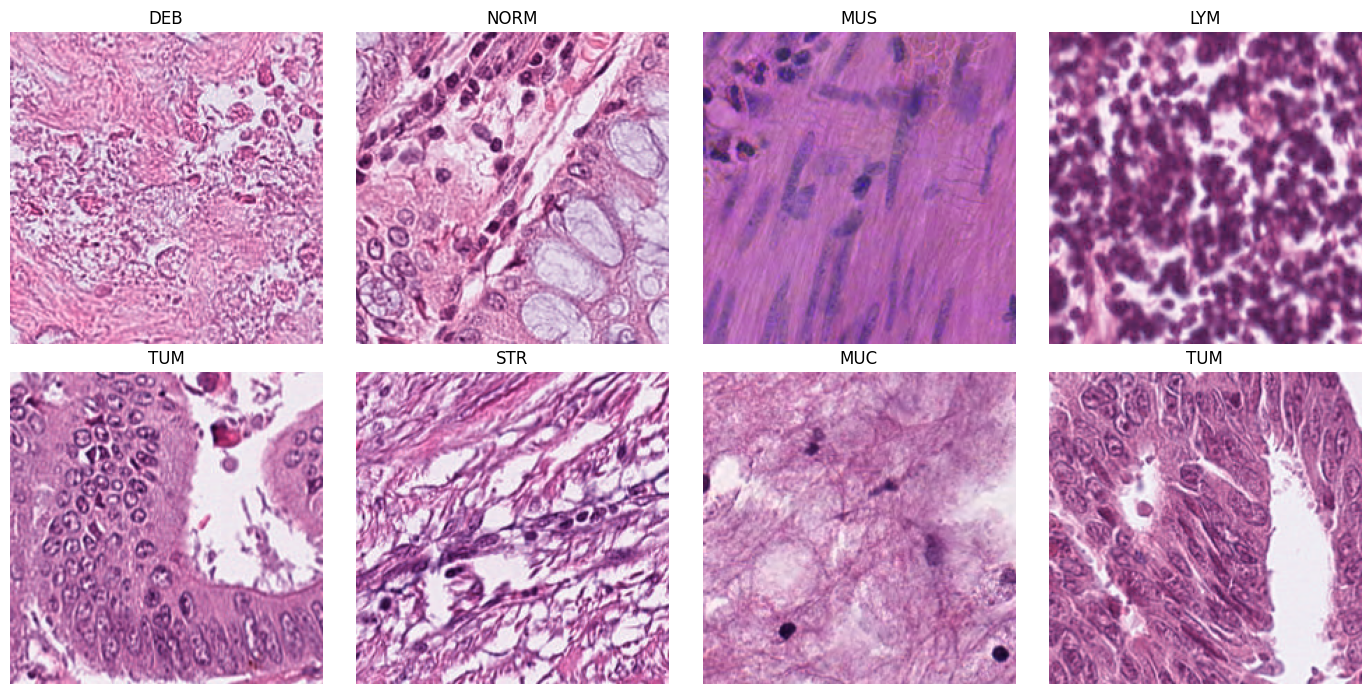

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    sample = dataset["train"][i]
    axes[i].imshow(sample["image"])
    axes[i].set_title(label_names[sample["label"]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Part A — ViT Baseline

## 8. Load a ViT baseline classifier

In [ ]:
baseline_model_name = "google/vit-base-patch16-224"

baseline_processor = AutoImageProcessor.from_pretrained(baseline_model_name, use_fast=True)
baseline_model = AutoModelForImageClassification.from_pretrained(
    baseline_model_name,
    num_labels=len(label_names),
    ignore_mismatched_sizes=True,
).to(device)

print("Baseline model loaded.")
if device == "cuda":
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([9, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([9])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Baseline model loaded.
GPU memory allocated: 0.34 GB


## 9. Prepare the dataset for ViT

In [ ]:
def vit_transform_batch(batch):
    images = batch["image"]
    inputs = baseline_processor(images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs

baseline_dataset = dataset.with_transform(vit_transform_batch)

## 10. Define metrics for the baseline

In [ ]:
accuracy = evaluate.load("accuracy")

def baseline_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

## 11. Baseline training arguments

In [ ]:
baseline_training_args = TrainingArguments(
    output_dir="./outputs/vit_baseline_results_v2",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    remove_unused_columns=False,
    report_to="none",
)

## 12. Train the baseline

In [ ]:
baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_training_args,
    train_dataset=baseline_dataset["train"],
    eval_dataset=baseline_dataset["test"],
    compute_metrics=baseline_compute_metrics,
)

baseline_train_output = baseline_trainer.train()
baseline_train_output

Epoch,Training Loss,Validation Loss,Accuracy
1,0.010263,0.013664,0.996150


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.05689251401722431, metrics={'train_runtime': 772.797, 'train_samples_per_second': 103.52, 'train_steps_per_second': 6.47, 'total_flos': 6.19974810943488e+18, 'train_loss': 0.05689251401722431, 'epoch': 1.0})

## 13. Evaluate the baseline

In [ ]:
baseline_pred_output = baseline_trainer.predict(baseline_dataset["test"])
baseline_pred_logits = baseline_pred_output.predictions
baseline_true_labels = baseline_pred_output.label_ids
baseline_metrics = baseline_compute_metrics((baseline_pred_logits, baseline_true_labels))
print(baseline_metrics)

{'accuracy': 0.99615}


## 14. Confusion matrix and classification report for the baseline

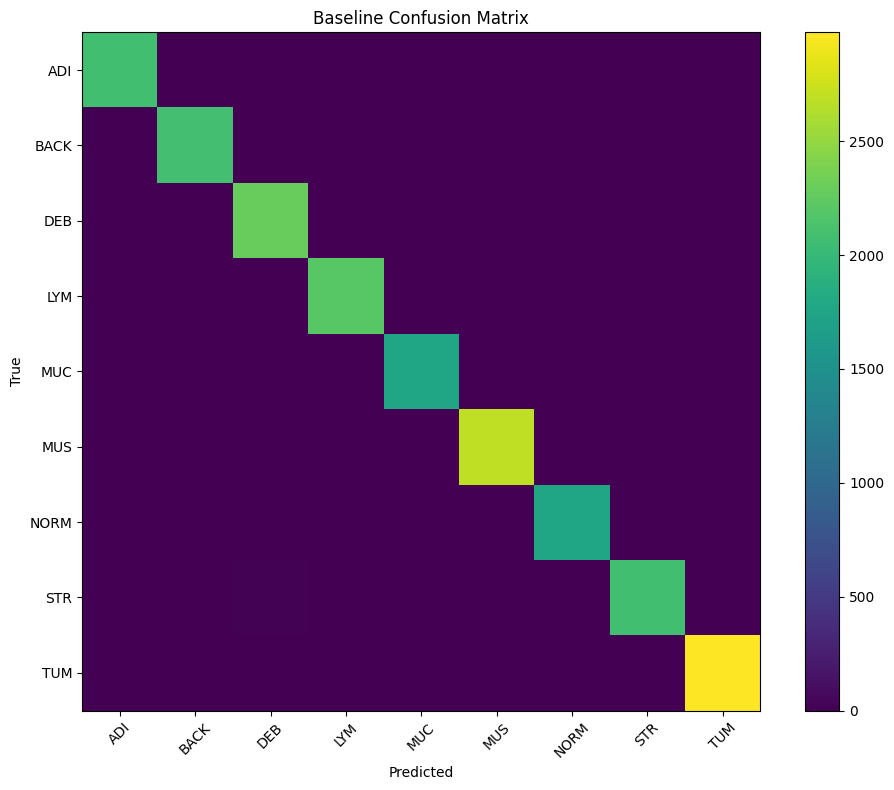

              precision    recall  f1-score   support

         ADI     0.9995    0.9995    0.9995      2076
        BACK     1.0000    1.0000    1.0000      2088
         DEB     0.9917    0.9965    0.9941      2291
         LYM     1.0000    0.9986    0.9993      2213
         MUC     0.9944    0.9955    0.9949      1771
         MUS     0.9985    0.9970    0.9978      2696
        NORM     0.9949    0.9933    0.9941      1779
         STR     0.9923    0.9895    0.9909      2093
         TUM     0.9940    0.9950    0.9945      2993

    accuracy                         0.9961     20000
   macro avg     0.9962    0.9961    0.9961     20000
weighted avg     0.9962    0.9961    0.9962     20000



In [ ]:
baseline_pred_output = baseline_trainer.predict(baseline_dataset["test"])
baseline_pred_logits = baseline_pred_output.predictions
baseline_true_labels = baseline_pred_output.label_ids
baseline_pred_labels = np.argmax(baseline_pred_logits, axis=1)

cm = confusion_matrix(baseline_true_labels, baseline_pred_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.yticks(range(len(label_names)), label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

baseline_report = classification_report(
    baseline_true_labels,
    baseline_pred_labels,
    target_names=label_names,
    digits=4,
)
print(baseline_report)

## 15. Save the baseline model

In [ ]:
baseline_save_dir = "./models/vit-baseline-v2"
baseline_trainer.save_model(baseline_save_dir)
baseline_processor.save_pretrained(baseline_save_dir)
print("Saved baseline model to:", baseline_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved baseline model to: ./models/vit-baseline-v2


# Part B — MedGemma Inference Check

## 16. Load MedGemma

In [ ]:
MEDGEMMA_MODEL_ID = "google/medgemma-1.5-4b-it"

med_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)
med_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

print("MedGemma loaded successfully.")

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

MedGemma loaded successfully.


## 17. Test MedGemma on one image

In [ ]:
CLASS_PROMPT = (
    "Classify this colorectal histology patch. "
    "Choose exactly one label from: ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM. "
    "Answer with only the label."
)

sample_image = dataset["test"][0]["image"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image},
            {"type": "text", "text": CLASS_PROMPT},
        ],
    }
]

chat_text = med_processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = med_processor(
    text=chat_text,
    images=sample_image,
    return_tensors="pt"
).to(med_model.device)

with torch.no_grad():
    outputs = med_model.generate(**inputs, max_new_tokens=10)

decoded = med_processor.batch_decode(outputs, skip_special_tokens=True)[0]
print(decoded)

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


user




Classify this colorectal histology patch. Choose exactly one label from: ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM. Answer with only the label.
model
Based on the image, the most likely classification is


# Part C — Improved MedGemma QLoRA Fine-Tuning for Histopathology

This version is designed to reduce prediction collapse like the confusion matrix where many classes are predicted as **MUS**. The important changes are:

- stratified train/test split earlier in the notebook
- balanced per-class training subset or oversampling
- stronger histopathology-style augmentation
- higher-capacity QLoRA adapters
- assistant-only label masking so the model is trained to predict the class answer instead of copying the whole prompt
- robust label parsing and row-normalized confusion matrix

Run this section instead of the original Part C cells if you are training MedGemma for the final model.

## 18. Reload MedGemma in 4-bit and attach stronger LoRA adapters

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

med_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)

med_model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

med_model = prepare_model_for_kbit_training(med_model)

# Larger adapter capacity than the first draft. The MLP modules help the language side map visual evidence to labels.
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

med_model = get_peft_model(med_model, lora_config)
med_model.print_trainable_parameters()

## 19. Improved classification prompt and balanced training subset

In [ ]:
LABEL_NAMES = label_names
LABEL_SET = set(LABEL_NAMES)

CLASS_PROMPT = (
    "You are classifying a colorectal H&E histopathology image patch.\n"
    "Choose exactly one tissue label from this closed set:\n"
    "ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM.\n"
    "Definitions: ADI=adipose, BACK=background, DEB=debris, LYM=lymphocytes, "
    "MUC=mucus, MUS=smooth muscle, NORM=normal mucosa, STR=stroma, TUM=tumor epithelium.\n"
    "Return only the uppercase label."
)

def convert_to_instruction_example(example):
    return {
        "image": example["image"],
        "label": example["label"],
        "prompt": CLASS_PROMPT,
        "answer": LABEL_NAMES[example["label"]],
    }

med_train_raw = dataset["train"].map(convert_to_instruction_example)
med_test_raw = dataset["test"].map(convert_to_instruction_example)

from collections import defaultdict, Counter
from datasets import Dataset
import random

# For Colab speed, cap the number of real examples per class. Increase on A100/L4 if you have time.
# Set MAX_TRAIN_PER_CLASS = None to use all images. Use 1000-3000 for a practical first run.
MAX_TRAIN_PER_CLASS = 2000

def make_balanced_dataset(ds, label_col="label", max_per_class=MAX_TRAIN_PER_CLASS, seed=SEED):
    rng = random.Random(seed)
    indices_by_class = defaultdict(list)
    for idx, label in enumerate(ds[label_col]):
        indices_by_class[int(label)].append(idx)

    if max_per_class is None:
        target_n = max(len(v) for v in indices_by_class.values())
    else:
        target_n = min(max_per_class, max(len(v) for v in indices_by_class.values()))

    selected = []
    for label, idxs in sorted(indices_by_class.items()):
        if len(idxs) >= target_n:
            selected.extend(rng.sample(idxs, target_n))
        else:
            # Oversample rare classes with replacement.
            selected.extend(idxs)
            selected.extend(rng.choices(idxs, k=target_n - len(idxs)))
    rng.shuffle(selected)
    return ds.select(selected)

balanced_med_train_raw = make_balanced_dataset(med_train_raw)
print("Original train label counts:", Counter(med_train_raw["label"]))
print("Balanced train label counts:", Counter(balanced_med_train_raw["label"]))
print("Balanced train size:", len(balanced_med_train_raw))
print("Validation size:", len(med_test_raw))

## 20. Histopathology augmentation and assistant-only label masking

In [ ]:
from dataclasses import dataclass
from typing import List, Dict, Any
from PIL import ImageEnhance, ImageFilter
import random
import torch

# Light stain/color augmentation. Avoid heavy transforms that destroy tissue morphology.
def augment_histology_image(img):
    img = img.convert("RGB")
    if random.random() < 0.5:
        img = img.transpose(0)  # FLIP_LEFT_RIGHT
    if random.random() < 0.5:
        img = img.transpose(1)  # FLIP_TOP_BOTTOM
    if random.random() < 0.75:
        img = img.rotate(random.choice([0, 90, 180, 270]))
    if random.random() < 0.8:
        img = ImageEnhance.Color(img).enhance(random.uniform(0.85, 1.20))
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.20))
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.90, 1.10))
    if random.random() < 0.2: # Mild blur augmentation
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))
    return img

@dataclass
class MedGemmaClassificationCollator:
    processor: Any
    train: bool = True
    max_length: int = 512

    def __call__(self, examples: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        full_texts = []
        prompt_texts = []
        images = []

        for ex in examples:
            img = ex["image"]
            if self.train:
                img = augment_histology_image(img)
            else:
                img = img.convert("RGB")
            images.append(img)

            user_msg = [{
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {"type": "text", "text": ex["prompt"]},
                ],
            }]
            full_msg = user_msg + [{
                "role": "assistant",
                "content": [{"type": "text", "text": ex["answer"]}],
            }]

            prompt_texts.append(self.processor.apply_chat_template(user_msg, tokenize=False, add_generation_prompt=True))
            full_texts.append(self.processor.apply_chat_template(full_msg, tokenize=False, add_generation_prompt=False))

        # For many vision-language processors, a batch of one image per example is represented as [[img], [img], ...].
        batched_images = [[img] for img in images]
        model_inputs = self.processor(
            text=full_texts,
            images=batched_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=self.max_length,
        )

        labels = model_inputs["input_ids"].clone()
        labels[model_inputs["attention_mask"] == 0] = -100

        # Mask the user prompt tokens. The loss should focus on the assistant class label only.
        for i, prompt_text in enumerate(prompt_texts):
            prompt_inputs = self.processor(
                text=prompt_text,
                images=[[images[i]]],
                return_tensors="pt",
                truncation=True,
                max_length=self.max_length,
            )
            prompt_len = int(prompt_inputs["input_ids"].shape[1])
            labels[i, :min(prompt_len, labels.shape[1])] = -100

        model_inputs["labels"] = labels
        return model_inputs

train_collator = MedGemmaClassificationCollator(med_processor, train=True, max_length=512)
eval_collator = MedGemmaClassificationCollator(med_processor, train=False, max_length=512)

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score
import re

# This pattern needs to be consistent with the CLASS_PROMPT and LABEL_NAMES
LABEL_PATTERN = re.compile(r"\b(ADI|BACK|DEB|LYM|MUC|MUS|NORM|STR|TUM)\b", re.IGNORECASE)

def extract_label_for_metric(decoded_text):
    text = decoded_text.upper()
    # Prefer text after assistant/model markers when present.
    for marker in ["MODEL", "ASSISTANT"]:
        if marker in text:
            text = text.split(marker)[-1]
    match = LABEL_PATTERN.search(text)
    return match.group(1).upper() if match else "UNKNOWN"

def medgemma_compute_metrics(eval_pred):
    predictions, labels_ids = eval_pred
    # Decode predictions (generated text) and true labels (ids to text)
    decoded_preds = med_processor.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = [LABEL_NAMES[label_id] for label_id in labels_ids if label_id != -100]

    # Extract predicted labels using the robust parser
    extracted_preds = [extract_label_for_metric(pred) for pred in decoded_preds]

    # Filter out UNKNOWN predictions for metric calculation
    valid_true_labels = []
    valid_extracted_preds = []
    for true_lbl, pred_lbl in zip(decoded_labels, extracted_preds):
        if pred_lbl in LABEL_NAMES: # Only consider predictions that are valid labels
            valid_true_labels.append(true_lbl)
            valid_extracted_preds.append(pred_lbl)

    if not valid_true_labels:
        return {"balanced_accuracy": 0.0, "macro_f1": 0.0, "invalid_pred_ratio": 1.0}

    # Convert labels to numerical format for sklearn metrics
    true_indices = [LABEL_NAMES.index(lbl) for lbl in valid_true_labels]
    pred_indices = [LABEL_NAMES.index(lbl) for lbl in valid_extracted_preds]

    balanced_acc = balanced_accuracy_score(true_indices, pred_indices)
    macro_f1 = f1_score(true_indices, pred_indices, average="macro", zero_division=0)

    invalid_pred_ratio = (len(extracted_preds) - len(valid_extracted_preds)) / len(extracted_preds) if len(extracted_preds) > 0 else 0.0

    return {
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "invalid_pred_ratio": invalid_pred_ratio
    }

## 21. QLoRA training arguments

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

med_training_args = TrainingArguments(
    output_dir="./outputs/medgemma_crc_qlora_improved",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=1e-4,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=250,
    save_steps=250,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1", # Track macro-F1 for early stopping
    greater_is_better=True,                # Higher F1 is better
    remove_unused_columns=False,
    bf16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    report_to="none",
)

## 22. Train improved MedGemma QLoRA

In [ ]:
def preprocess_logits_for_metrics(logits, labels):
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)

med_trainer = Trainer(
    model=med_model,
    args=med_training_args,
    train_dataset=balanced_med_train_raw,
    eval_dataset=med_test_raw.shuffle(seed=SEED).select(range(min(1000, len(med_test_raw)))),
    data_collator=train_collator,
    compute_metrics=medgemma_compute_metrics,
    preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

med_train_output = med_trainer.train()
med_train_output

## 23. Save improved MedGemma LoRA adapters

In [ ]:
med_save_dir = "./models/medgemma-crc-qlora-improved"
med_trainer.save_model(med_save_dir)
med_processor.save_pretrained(med_save_dir)
print("Saved improved MedGemma adapters to:", med_save_dir)

## 24. Robust MedGemma prediction and evaluation helpers

In [ ]:
import re
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

LABEL_PATTERN = re.compile(r"\b(ADI|BACK|DEB|LYM|MUC|MUS|NORM|STR|TUM)\b", re.IGNORECASE)

def extract_label_from_generation(decoded_text):
    text = decoded_text.upper()
    # Prefer text after assistant/model markers when present.
    for marker in ["MODEL", "ASSISTANT"]:
        if marker in text:
            text = text.split(marker)[-1]
    match = LABEL_PATTERN.search(text)
    return match.group(1).upper() if match else "UNKNOWN"

@torch.no_grad()
def predict_with_medgemma_label(image):
    med_model.eval()
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image.convert("RGB")},
            {"type": "text", "text": CLASS_PROMPT},
        ],
    }]
    prompt = med_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = med_processor(text=prompt, images=image.convert("RGB"), return_tensors="pt").to(med_model.device)
    output = med_model.generate(
        **inputs,
        max_new_tokens=4,
        do_sample=False,
        num_beams=1,
        pad_token_id=med_processor.tokenizer.eos_token_id,
    )
    decoded = med_processor.batch_decode(output, skip_special_tokens=True)[0]
    return extract_label_from_generation(decoded)

def evaluate_medgemma_generation(eval_ds, max_examples=1000):
    eval_subset = eval_ds.shuffle(seed=SEED).select(range(min(max_examples, len(eval_ds))))
    y_true, y_pred = [], []
    for i, ex in enumerate(eval_subset):
        if i % 50 == 0:
            print(f"Evaluating {i}/{len(eval_subset)}")
        pred = predict_with_medgemma_label(ex["image"])
        y_pred.append(pred)
        y_true.append(LABEL_NAMES[ex["label"]])

    valid_mask = [p in LABEL_NAMES for p in y_pred]
    y_true_idx = [LABEL_NAMES.index(t) for t, ok in zip(y_true, valid_mask) if ok]
    y_pred_idx = [LABEL_NAMES.index(p) for p, ok in zip(y_pred, valid_mask) if ok]

    print("Unknown predictions:", len(y_pred) - sum(valid_mask), "of", len(y_pred))
    print("Balanced accuracy:", balanced_accuracy_score(y_true_idx, y_pred_idx))
    print("Macro F1:", f1_score(y_true_idx, y_pred_idx, average="macro"))
    print(classification_report(y_true_idx, y_pred_idx, target_names=LABEL_NAMES, digits=4, zero_division=0))
    return y_true, y_pred

## 25. Row-normalized confusion matrix for MedGemma

In [ ]:
# Increase max_examples when you are ready for a full evaluation.
medgemma_true_labels, medgemma_predictions = evaluate_medgemma_generation(med_test_raw, max_examples=1000)

valid_pairs = [(t, p) for t, p in zip(medgemma_true_labels, medgemma_predictions) if p in LABEL_NAMES]
y_true_idx = [LABEL_NAMES.index(t) for t, p in valid_pairs]
y_pred_idx = [LABEL_NAMES.index(p) for t, p in valid_pairs]

cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(LABEL_NAMES))))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Raw Confusion Matrix
im0 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title("Improved MedGemma QLoRA Confusion Matrix - Raw")
axes[0].set_xticks(range(len(LABEL_NAMES)))
axes[0].set_xticklabels(LABEL_NAMES, rotation=45)
axes[0].set_yticks(range(len(LABEL_NAMES)))
axes[0].set_yticklabels(LABEL_NAMES)
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
for i in range(len(LABEL_NAMES)):
    for j in range(len(LABEL_NAMES)):
        axes[0].text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8, color="black" if cm[i, j] < cm.max()/2 else "white")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Normalized Confusion Matrix
im1 = axes[1].imshow(cm_norm, vmin=0, vmax=1, cmap='Blues')
axes[1].set_title("Improved MedGemma QLoRA Confusion Matrix - Row Normalized")
axes[1].set_xticks(range(len(LABEL_NAMES)))
axes[1].set_xticklabels(LABEL_NAMES, rotation=45)
axes[1].set_yticks(range(len(LABEL_NAMES)))
axes[1].set_yticklabels(LABEL_NAMES)
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
for i in range(len(LABEL_NAMES)):
    for j in range(len(LABEL_NAMES)):
        axes[1].text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black" if cm_norm[i, j] < 0.5 else "white")
fig.colorbar(im1, ax=axes[1], label="Recall within true class", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("./outputs/confusion_matrices_medgemma_improved.png", dpi=200)
plt.show()

## 25b. Error Analysis: Visualizing Misclassifications

In [ ]:
import matplotlib.pyplot as plt

# Find misclassified indices
misclassified_idx = [i for i, (true_lbl, pred_lbl) in enumerate(zip(medgemma_true_labels, medgemma_predictions)) if true_lbl != pred_lbl and pred_lbl in LABEL_NAMES]

if not misclassified_idx:
    print("No misclassified examples found in the subset!")
else:
    # Display up to 8 misclassified examples
    num_to_display = min(8, len(misclassified_idx))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_to_display):
        idx = misclassified_idx[i]
        ex = med_test_raw[idx]
        img = ex["image"]
        true_label = medgemma_true_labels[idx]
        pred_label = medgemma_predictions[idx]

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color="red")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Part D — Demo Helpers

## 26. Baseline single-image prediction helper

In [ ]:
def predict_with_baseline(image):
    baseline_model.eval()
    inputs = baseline_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = baseline_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    return {
        "predicted_label": label_names[pred_idx],
        "confidence": float(probs[pred_idx]),
        "scores": {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    }

## 27. MedGemma single-image prediction helper

In [ ]:
def predict_with_medgemma(image):
    med_model.eval()

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": CLASS_PROMPT},
            ],
        }
    ]

    prompt = med_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = med_processor(
        text=prompt,
        images=image,
        return_tensors="pt",
    ).to(med_model.device)

    with torch.no_grad():
        output = med_model.generate(**inputs, max_new_tokens=10)

    return med_processor.batch_decode(output, skip_special_tokens=True)[0]

## 28. Simple Gradio demo scaffold

In [ ]:
import gradio as gr
import pandas as pd

def demo_predict(image):
    baseline_result = predict_with_baseline(image)
    medgemma_result = predict_with_medgemma(image)

    scores_df = pd.DataFrame({
        "Tissue Class": list(baseline_result["scores"].keys()),
        "Confidence": list(baseline_result["scores"].values()),
    }).sort_values("Confidence", ascending=False)

    return (
        baseline_result["predicted_label"],
        baseline_result["confidence"],
        scores_df,
        medgemma_result,
    )

demo = gr.Interface(
    fn=demo_predict,
    inputs=gr.Image(type="pil", label="Upload Histology Patch"),
    outputs=[
        gr.Textbox(label="ViT Baseline Prediction"),
        gr.Number(label="ViT Confidence"),
        gr.Dataframe(label="ViT Confidence Scores"),
        gr.Textbox(label="MedGemma Output"),
    ],
    title="Clinical Decision Support System for Colorectal Histology",
    description="Upload a histology patch and compare the ViT baseline against MedGemma."
)

# To launch in Colab, uncomment:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8f8d584f03ae7c90ec.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 29. Results summary template

In [ ]:
results_summary = {
    "baseline_model": baseline_model_name,
    "baseline_metrics": baseline_metrics if "baseline_metrics" in globals() else None,
    "medgemma_model": MEDGEMMA_MODEL_ID,
    "notes": [
        "Record the final baseline accuracy.",
        "Record the final MedGemma qualitative outputs or evaluation strategy.",
        "Describe which classes were most commonly confused.",
        "Explain whether MedGemma improved clinical-style reasoning or output quality."
    ]
}

results_summary

{'baseline_model': 'google/vit-base-patch16-224',
 'baseline_metrics': {'accuracy': 0.99615},
 'medgemma_model': 'google/medgemma-1.5-4b-it',
 'notes': ['Record the final baseline accuracy.',
  'Record the final MedGemma qualitative outputs or evaluation strategy.',
  'Describe which classes were most commonly confused.',
  'Explain whether MedGemma improved clinical-style reasoning or output quality.']}

## 30. Suggested final report structure
- Problem statement
- Dataset description
- Baseline model and results
- MedGemma + QLoRA setup
- Comparison between baseline and MedGemma
- Demo description
- Limitations and future work

## A. Final Deliverables Checklist

1.  **Evaluation Artifacts (`final_results` folder in Google Drive):**
    *   `metrics.json`
    *   `classification_report_baseline.csv`
    *   `classification_report_medgemma.csv`
    *   `confusion_matrix_baseline.png`
    *   `confusion_matrix_medgemma.png`
    *   `predictions.csv`
    *   `comparison_summary.csv`
2.  **Gradio Demo App:**
    *   Interactive web interface for image upload.
    *   Displays baseline and MedGemma predictions, confidence scores, and a clinical-style explanation.
3.  **Project Zip Archive (`final_submission.zip`):**
    *   Includes the final notebook.
    *   Includes the `final_results` folder.
    *   Includes the `models` folder (from Google Drive backup).
4.  **Suggested Screenshots/Figures for Presentation.**

## B. Artifact Generation Steps

First, let's define some constants for file paths and ensure your Google Drive is mounted and accessible. We'll then download the `CRC-VAL-HE-7K` dataset (your specified test dataset) and load your saved models from Google Drive.

### 32. Define Constants and Verify Google Drive Mount

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import PeftModel

# --- Project Specific Constants ---
DRIVE_PATH = '/content/drive/MyDrive/MedGemma_Colorectal_Project_v2'
VIT_BASELINE_PATH = os.path.join(DRIVE_PATH, 'models', 'vit-baseline-v2')
MEDGEMMA_QLORA_PATH = os.path.join(DRIVE_PATH, 'models', 'medgemma-crc-qlora-improved')
FINAL_RESULTS_DIR = os.path.join(DRIVE_PATH, 'final_results')

# CRC-VAL-HE-7K Dataset (Zenodo URL)
CRC_VAL_HE_7K_URL = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
CRC_VAL_HE_7K_ZIP_NAME = "CRC-VAL-HE-7K.zip"
CRC_VAL_HE_7K_DIR = "data/CRC-VAL-HE-7K"

# Label names are consistent across both datasets based on project context
LABEL_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
NUM_LABELS = len(LABEL_NAMES)

# MedGemma specific constants
MEDGEMMA_MODEL_ID = "google/medgemma-1.5-4b-it"
CLASS_PROMPT = (
    "Classify this colorectal histology patch. "
    "Choose exactly one label from: ADI, BACK, DEB, LYM, MUC, MUS, NORM, STR, TUM. "
    "Answer with only the label."
)

# Ensure output directories exist
os.makedirs(FINAL_RESULTS_DIR, exist_ok=True)

# Verify Google Drive mount (if not already mounted from earlier cells)
if not os.path.exists(DRIVE_PATH):
    from google.colab import drive
    drive.mount('/content/drive')

print("Constants defined and Drive path verified.")

Constants defined and Drive path verified.


### 33. Download and Load the CRC-VAL-HE-7K Test Dataset

We will download the `CRC-VAL-HE-7K` dataset from Zenodo, which is a separate validation dataset of 7,180 images. This will be used for final evaluation, distinct from the `NCT-CRC-HE-100K` test split used during training.

In [ ]:
# Check if CRC-VAL-HE-7K is already downloaded
if not os.path.exists(CRC_VAL_HE_7K_DIR):
    print(f"Downloading {CRC_VAL_HE_7K_ZIP_NAME}...")
    !wget -O {CRC_VAL_HE_7K_ZIP_NAME} {CRC_VAL_HE_7K_URL}
    print(f"Extracting {CRC_VAL_HE_7K_ZIP_NAME}...")
    !unzip -q {CRC_VAL_HE_7K_ZIP_NAME} -d data/
    print("CRC-VAL-HE-7K dataset downloaded and extracted.")
else:
    print("CRC-VAL-HE-7K dataset already exists.")

# Load the dataset using imagefolder
crc_val_dataset = load_dataset("imagefolder", data_dir=CRC_VAL_HE_7K_DIR)
# The CRC-VAL-HE-7K dataset is usually just a test set, so we'll use its 'train' split as the 'test' set.
crc_val_test_dataset = crc_val_dataset["train"]

print(f"CRC-VAL-HE-7K dataset loaded. Number of samples: {len(crc_val_test_dataset)}")
print(crc_val_test_dataset)

# Set device globally if not already set
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device for evaluation:", device)

--2026-05-04 17:27:23--  https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 800276929 (763M) [application/octet-stream]
Saving to: ‘CRC-VAL-HE-7K.zip’

CRC-VAL-HE-7K.zip   100%[===================>] 763.20M  17.9MB/s    in 12m 41s 

2026-05-04 17:40:05 (1.00 MB/s) - ‘CRC-VAL-HE-7K.zip’ saved [800276929/800276929]

Extracting CRC-VAL-HE-7K.zip...
CRC-VAL-HE-7K dataset downloaded and extracted.


Resolving data files:   0%|          | 0/7180 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

CRC-VAL-HE-7K dataset loaded. Number of samples: 7180
Dataset({
    features: ['image', 'label'],
    num_rows: 7180
})
Device for evaluation: cuda


### 34. Load Saved Models from Google Drive

We will load the ViT baseline model and the MedGemma model with its QLoRA adapters from the paths where you saved them in your Google Drive.

In [ ]:
import os
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification, AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import PeftModel

# Fallback to local models if Drive models aren't copied yet
actual_vit_path = VIT_BASELINE_PATH if os.path.exists(VIT_BASELINE_PATH) else ("./models/vit-baseline-v2" if os.path.exists("./models/vit-baseline-v2") else "google/vit-base-patch16-224")
actual_med_path = MEDGEMMA_QLORA_PATH if os.path.exists(MEDGEMMA_QLORA_PATH) else ("./models/medgemma-crc-qlora-improved" if os.path.exists("./models/medgemma-crc-qlora-improved") else None)

# --- Load ViT Baseline Model ---
print(f"Loading ViT baseline model from: {actual_vit_path}")
vit_baseline_processor = AutoImageProcessor.from_pretrained(actual_vit_path, use_fast=False)
vit_baseline_model = AutoModelForImageClassification.from_pretrained(
    actual_vit_path,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True,
    id2label={i: label for i, label in enumerate(LABEL_NAMES)},
    label2id={label: i for i, label in enumerate(LABEL_NAMES)},
).to(device)
vit_baseline_model.eval()
print("ViT Baseline Model loaded.")

Loading ViT baseline model from: ./models/vit-baseline-v2


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Baseline Model loaded.


In [ ]:
!pip install -q -U bitsandbytes>=0.46.1

# --- Load MedGemma Model ---
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

med_processor = AutoProcessor.from_pretrained(MEDGEMMA_MODEL_ID)
med_model_base = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

if actual_med_path:
    print(f"Loading MedGemma with QLoRA adapters from: {actual_med_path}")
    med_model = PeftModel.from_pretrained(med_model_base, actual_med_path)
    med_model = med_model.merge_and_unload()
else:
    print(f"Loading base MedGemma model (no QLoRA adapters found).")
    med_model = med_model_base

med_model.eval()
print("MedGemma Model loaded.")

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading MedGemma with QLoRA adapters from: ./models/medgemma-crc-qlora-v2


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:373: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


MedGemma Model loaded.


### 35. Prepare CRC-VAL-HE-7K Dataset for Inference

We need to apply the correct preprocessing transformations for each model.

In [ ]:
# --- For ViT Baseline ---
def vit_transform_batch_eval(batch):
    images = batch["image"]
    inputs = vit_baseline_processor(images=images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs

vit_eval_dataset = crc_val_test_dataset.with_transform(vit_transform_batch_eval)
print("ViT evaluation dataset prepared.")

# --- For MedGemma (instruction tuning format) ---
def convert_to_instruction_example_eval(example):
    return {
        "image": example["image"],
        "prompt": CLASS_PROMPT,
        "answer": LABEL_NAMES[example["label"]],
        "true_label": LABEL_NAMES[example["label"]]
    }

medgemma_eval_raw = crc_val_test_dataset.map(convert_to_instruction_example_eval)
print("MedGemma evaluation raw dataset prepared.")

ViT evaluation dataset prepared.


Map:   0%|          | 0/7180 [00:00<?, ? examples/s]

MedGemma evaluation raw dataset prepared.


### 36. Run Predictions on CRC-VAL-HE-7K

We'll run inference for both models and store their predictions.

In [ ]:
print("Running ViT Baseline predictions...")
vit_predictions = []
vit_true_labels = []

from torch.utils.data import DataLoader
def collate_fn_vit(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    labels = torch.tensor([item["labels"] for item in batch])
    return {"pixel_values": pixel_values, "labels": labels}

vit_dataloader = DataLoader(vit_eval_dataset, batch_size=32, collate_fn=collate_fn_vit)

with torch.no_grad():
    for batch in vit_dataloader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        outputs = vit_baseline_model(pixel_values=pixel_values)
        predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        vit_predictions.extend(predictions)
        vit_true_labels.extend(labels.cpu().numpy())

vit_predictions = np.array(vit_predictions)
vit_true_labels = np.array(vit_true_labels)
print("ViT Baseline predictions complete.")

print("Running MedGemma predictions (this might take a while)...")
medgemma_predictions = []
medgemma_true_labels = []

def get_medgemma_prediction(image, true_label):
    messages = [
        {"role": "user", "content": [{"type": "image", "image": image}, {"type": "text", "text": CLASS_PROMPT}]},
    ]
    chat_text = med_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = med_processor(text=chat_text, images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = med_model.generate(**inputs, max_new_tokens=10, do_sample=False, temperature=0.0)
    decoded_output = med_processor.batch_decode(outputs, skip_special_tokens=True)[0]
    generated_text = decoded_output.split('model')[-1].strip()
    predicted_label = generated_text.split(' ')[0].strip().upper()
    if predicted_label not in LABEL_NAMES:
        predicted_label = "UNKNOWN"
    return predicted_label

# Evaluate on the full validation dataset
medgemma_eval_subset = medgemma_eval_raw.shuffle(seed=42)

for i, sample in enumerate(medgemma_eval_subset):
    if i % 100 == 0:
        print(f"Processing MedGemma sample {i}/{len(medgemma_eval_subset)}")
    predicted = get_medgemma_prediction(sample["image"], sample["true_label"])
    medgemma_predictions.append(predicted)
    medgemma_true_labels.append(sample["true_label"])

medgemma_pred_indices = [LABEL_NAMES.index(p) if p in LABEL_NAMES else -1 for p in medgemma_predictions]
medgemma_true_indices = [LABEL_NAMES.index(t) for t in medgemma_true_labels]

valid_medgemma_predictions = [pred for pred, idx in zip(medgemma_predictions, medgemma_pred_indices) if idx != -1]
valid_medgemma_true_labels = [true for true, idx in zip(medgemma_true_labels, medgemma_pred_indices) if idx != -1]
valid_medgemma_pred_indices = [idx for idx in medgemma_pred_indices if idx != -1]
valid_medgemma_true_indices = [idx for idx, pred_idx in zip(medgemma_true_indices, medgemma_pred_indices) if pred_idx != -1]

print("MedGemma predictions complete.")

Running ViT Baseline predictions...


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


ViT Baseline predictions complete.
Running MedGemma predictions (this might take a while)...
Processing MedGemma sample 0/7180


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[

Processing MedGemma sample 100/7180


...

Processing MedGemma sample 7000/7180


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[tra

Processing MedGemma sample 7100/7180


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
[tra

MedGemma predictions complete.


### 37. Generate Evaluation Artifacts

Now we'll compute metrics and save all required artifacts to the `final_results` folder in your Google Drive.

In [ ]:
# --- 1. Metrics.json ---
metrics = {}

# ViT Baseline Metrics
vit_accuracy = np.mean(vit_predictions == vit_true_labels)
metrics["vit_baseline"] = {"accuracy": float(vit_accuracy)}
print(f"ViT Baseline Accuracy: {vit_accuracy:.4f}")

# MedGemma Metrics
if len(valid_medgemma_predictions) > 0:
    medgemma_accuracy = np.mean(np.array(valid_medgemma_pred_indices) == np.array(valid_medgemma_true_indices))
    metrics["medgemma_qlora"] = {"accuracy": float(medgemma_accuracy)}
    print(f"MedGemma QLoRA Accuracy (valid predictions): {medgemma_accuracy:.4f}")
else:
    metrics["medgemma_qlora"] = {"accuracy": 0.0, "note": "No valid MedGemma predictions to calculate accuracy."}
    print("Warning: No valid MedGemma predictions to calculate accuracy.")

with open(os.path.join(FINAL_RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)
print("metrics.json generated.")

# --- 2. Classification Reports (CSV) ---
# ViT Baseline
vit_report = classification_report(vit_true_labels, vit_predictions, target_names=LABEL_NAMES, labels=range(len(LABEL_NAMES)), output_dict=True, zero_division=0)
pd.DataFrame(vit_report).transpose().to_csv(os.path.join(FINAL_RESULTS_DIR, "classification_report_baseline.csv"))
print("classification_report_baseline.csv generated.")

# MedGemma (only for valid predictions)
if len(valid_medgemma_predictions) > 0:
    medgemma_report = classification_report(valid_medgemma_true_indices, valid_medgemma_pred_indices, target_names=LABEL_NAMES, labels=range(len(LABEL_NAMES)), output_dict=True, zero_division=0)
    pd.DataFrame(medgemma_report).transpose().to_csv(os.path.join(FINAL_RESULTS_DIR, "classification_report_medgemma.csv"))
    print("classification_report_medgemma.csv generated.")
else:
    print("Skipping classification_report_medgemma.csv due to no valid MedGemma predictions.")

# --- 3. Confusion Matrices (PNG) ---
def plot_confusion_matrix(y_true, y_pred, labels, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(os.path.join(FINAL_RESULTS_DIR, filename))
    plt.close()

# ViT Baseline
plot_confusion_matrix(vit_true_labels, vit_predictions, LABEL_NAMES, "ViT Baseline Confusion Matrix", "confusion_matrix_baseline.png")
print("confusion_matrix_baseline.png generated.")

# MedGemma
if len(valid_medgemma_predictions) > 0:
    plot_confusion_matrix(valid_medgemma_true_indices, valid_medgemma_pred_indices, LABEL_NAMES, "MedGemma QLoRA Confusion Matrix", "confusion_matrix_medgemma.png")
    print("confusion_matrix_medgemma.png generated.")
else:
    print("Skipping confusion_matrix_medgemma.png due to no valid MedGemma predictions.")

# --- 4. Predictions.csv ---
predictions_df = pd.DataFrame({
    'image_path': [sample['image'].filename for sample in medgemma_eval_subset], # Use medgemma_eval_subset for image paths
    'true_label': medgemma_true_labels,
    'vit_baseline_prediction': [LABEL_NAMES[p] for p in vit_predictions[:len(medgemma_eval_subset)]], # Match subset size
    'medgemma_qlora_prediction': medgemma_predictions
})
predictions_df.to_csv(os.path.join(FINAL_RESULTS_DIR, "predictions.csv"), index=False)
print("predictions.csv generated.")

# --- 5. Comparison Summary.csv ---
comparison_summary = pd.DataFrame({
    'Model': ['ViT Baseline', 'MedGemma QLoRA'],
    'Accuracy': [metrics['vit_baseline']['accuracy'], metrics['medgemma_qlora']['accuracy']],
    'Notes': [
        'Baseline model trained on NCT-CRC-HE-100K train split, evaluated on CRC-VAL-HE-7K.',
        'MedGemma fine-tuned with QLoRA on NCT-CRC-HE-100K train split, evaluated on CRC-VAL-HE-7K (valid predictions only).'
    ]
})
comparison_summary.to_csv(os.path.join(FINAL_RESULTS_DIR, "comparison_summary.csv"), index=False)
print("comparison_summary.csv generated.")

print("All evaluation artifacts have been generated and saved to", FINAL_RESULTS_DIR)


ViT Baseline Accuracy: 0.9713
MedGemma QLoRA Accuracy (valid predictions): 0.2602
metrics.json generated.
classification_report_baseline.csv generated.
classification_report_medgemma.csv generated.
confusion_matrix_baseline.png generated.
confusion_matrix_medgemma.png generated.
predictions.csv generated.
comparison_summary.csv generated.
All evaluation artifacts have been generated and saved to /content/drive/MyDrive/MedGemma_Colorectal_Project_v2/final_results


### 38. Verify Artifacts in Google Drive

Run the following command to list the contents of your `final_results` directory in Google Drive to confirm all artifacts are saved.

In [ ]:
!ls -lh "{FINAL_RESULTS_DIR}"

total 170K
-rw------- 1 root root 792 May  4 18:32 classification_report_baseline.csv
-rw------- 1 root root 821 May  4 18:32 classification_report_medgemma.csv
-rw------- 1 root root 291 May  4 18:33 comparison_summary.csv
-rw------- 1 root root 36K May  4 18:32 confusion_matrix_baseline.png
-rw------- 1 root root 37K May  4 18:32 confusion_matrix_medgemma.png
-rw------- 1 root root 141 May  4 18:32 metrics.json
-rw------- 1 root root 95K May  4 18:33 predictions.csv


## C. Gradio App Code & D. How to Run the Gradio App in Colab

Now, let's set up the Gradio application for your demo. We will reuse and modify the existing helper functions to ensure they use the globally loaded models (`vit_baseline_model`, `vit_baseline_processor`, `med_model`, `med_processor`). We'll also enhance the `demo_predict` function to include a clinical-style explanation.

### 39. Modified Prediction Helper Functions

We'll modify the existing helper functions (`predict_with_baseline` and `predict_with_medgemma`) to ensure they use the models loaded from Drive and are ready for the Gradio demo. The original functions (cells `ByrRzMgb0INC` and `234W052Y0INC`) will be overwritten here to use the globally defined models.

In [ ]:
import gradio as gr
import pandas as pd
import torch
import numpy as np
import string
from PIL import Image

def predict_with_baseline(image: Image.Image):
    vit_baseline_model.eval() # Ensure model is in evaluation mode
    inputs = vit_baseline_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = vit_baseline_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    return {
        "predicted_label": LABEL_NAMES[pred_idx],
        "confidence": float(probs[pred_idx]),
        "scores": {LABEL_NAMES[i]: float(probs[i]) for i in range(len(LABEL_NAMES))}
    }

def predict_with_medgemma(image: Image.Image):
    med_model.eval() # Ensure model is in evaluation mode

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": CLASS_PROMPT},
            ],
        }
    ]

    prompt = med_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = med_processor(
        text=prompt,
        images=image,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        # Removed temperature to avoid warnings, increased max tokens slightly in case it's wordy
        output = med_model.generate(**inputs, max_new_tokens=15, do_sample=False)

    decoded_output = med_processor.batch_decode(output, skip_special_tokens=True)[0]

    # Safely extract generated text after the prompt
    if 'model\n' in decoded_output:
        generated_text = decoded_output.split('model\n')[-1].strip()
    elif 'model' in decoded_output:
        generated_text = decoded_output.split('model')[-1].strip()
    else:
        generated_text = decoded_output.strip()

    # Attempt to grab just the first word and strip punctuation
    predicted_label = generated_text.split('\n')[0].split(' ')[0].strip().upper()
    predicted_label = predicted_label.translate(str.maketrans('', '', string.punctuation))

    if predicted_label not in LABEL_NAMES:
        return f"UNKNOWN (Raw output: '{generated_text}')"
    return predicted_label

print("Prediction helper functions updated.")

Prediction helper functions updated.


### 40. Gradio Demo Application

This code sets up the Gradio interface. It includes a `demo_predict` function that orchestrates the predictions from both models and generates a clinical-style summary.

In [ ]:
def demo_predict(image):
    if image is None:
        return "", 0.0, pd.DataFrame(), "", "Please upload an image to classify."

    # --- Baseline Prediction ---
    baseline_result = predict_with_baseline(image)
    baseline_pred_label = baseline_result["predicted_label"]
    baseline_confidence = baseline_result["confidence"]
    baseline_scores_df = pd.DataFrame({
        "Tissue Class": list(baseline_result["scores"].keys()),
        "Confidence": list(baseline_result["scores"].values()),
    }).sort_values("Confidence", ascending=False).round(4)

    # --- MedGemma Prediction ---
    medgemma_pred_raw = predict_with_medgemma(image)

    # Clinical-style explanation
    clinical_explanation = f"The ViT Baseline model identifies the tissue as **{baseline_pred_label}** with a confidence of {baseline_confidence:.2%}. "

    if medgemma_pred_raw in LABEL_NAMES:
        clinical_explanation += f"The fine-tuned MedGemma model independently classifies this as **{medgemma_pred_raw}**. "
        if baseline_pred_label == medgemma_pred_raw:
            clinical_explanation += "Both models are in agreement, suggesting a strong consensus on the classification."
        else:
            clinical_explanation += "There is a discrepancy between the models. Further clinical review may be warranted."
    else:
        clinical_explanation += f"MedGemma's output for this image was: '{medgemma_pred_raw}'. This suggests uncertainty or a possible out-of-domain case for the generative model, requiring closer inspection."


    return (
        baseline_pred_label,
        baseline_confidence,
        baseline_scores_df,
        medgemma_pred_raw,
        clinical_explanation
    )

demo = gr.Interface(
    fn=demo_predict,
    inputs=gr.Image(type="pil", label="Upload Histology Patch"),
    outputs=[
        gr.Textbox(label="ViT Baseline Prediction"),
        gr.Number(label="ViT Confidence"),
        gr.Dataframe(label="ViT Confidence Scores (Baseline)", headers=["Tissue Class", "Confidence"]),
        gr.Textbox(label="MedGemma Output"),
        gr.Textbox(label="Clinical Summary"),
    ],
    title="Clinical Decision Support System for Colorectal Histology",
    description="Upload a histology patch to get classifications and a clinical summary from a ViT baseline and fine-tuned MedGemma model. Please use PNG or JPG images."
)

print("Gradio interface defined. To launch, uncomment `demo.launch(share=True)` below and run the cell.")

# --- How to run the Gradio app in Colab ---
# Uncomment the line below and run this cell to launch the demo.
# The link will be provided in the output. Keep this tab open while using the demo.

demo.launch(share=True)

Gradio interface defined. To launch, uncomment `demo.launch(share=True)` below and run the cell.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://280957fffb7e688b99.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## E. What Files to Include in the Final Zip

To prepare your final submission, you should create a `.zip` archive containing the following:

1.  **Your Colab Notebook:** Save the final version of this `.ipynb` file.
2.  **`MedGemma_Colorectal_Project` folder:** This is the top-level folder you created in your Google Drive. It should contain:
    *   `models/`: Your saved `vit-baseline` and `medgemma-crc-qlora` directories.
    *   `final_results/`: All the generated `.json`, `.csv`, and `.png` artifacts.
3.  **`data/NCT-CRC-HE-100K` and `data/CRC-VAL-HE-7K`:** If you want to include the datasets directly in your submission for reproducibility, otherwise, you can just mention their source.

**To create the zip file:**

```bash
# Navigate to your Drive project folder
cd /content/drive/MyDrive/MedGemma_Colorectal_Project

# Create a zip archive of the models and final_results
zip -r final_submission.zip models/ final_results/

# You can also include the dataset if desired, but it will be very large:
# cd /content/drive/MyDrive/
# zip -r MedGemma_Colorectal_Project.zip MedGemma_Colorectal_Project/

# You can then download `final_submission.zip` from your Google Drive
```

## F. Suggested Screenshots/Figures for the Presentation

Here are some ideas for compelling visuals for your presentation and report:

1.  **Dataset Samples:** A grid of 6-8 sample images from the `NCT-CRC-HE-100K` and `CRC-VAL-HE-7K` datasets, clearly labeled with their tissue types. (You already have a similar cell for this).
2.  **ViT Baseline Performance:**
    *   **Accuracy Score:** A simple bar chart showing the baseline accuracy.
    *   **Confusion Matrix:** The `confusion_matrix_baseline.png` will be excellent to show which classes were confused.
    *   **Classification Report Snippet:** Highlight precision, recall, and F1-score for a few key classes.
3.  **MedGemma + QLoRA Performance:**
    *   **Accuracy Score:** A simple bar chart comparing MedGemma's accuracy to the baseline's.
    *   **Confusion Matrix:** The `confusion_matrix_medgemma.png` for comparison.
    *   **Classification Report Snippet:** Similar to baseline, for comparison.
4.  **Model Comparison:** A table or bar chart comparing the overall accuracy of the ViT Baseline and MedGemma + QLoRA (from `comparison_summary.csv`).
5.  **Gradio Demo Screenshot:** A screenshot of your running Gradio application, showing an uploaded image, the predictions from both models, confidence scores, and the clinical summary. This demonstrates the practical application of your work.
6.  **

## 31. Backup progress to Google Drive
Run the cells below to mount your Google Drive and copy your trained models and outputs so they are not lost when the session disconnects.

In [ ]:
import os
from google.colab import drive

# Check if drive is already mounted to prevent the ValueError
if not os.path.exists('/content/drive/MyDrive'):
    # This will prompt you to authorize Colab to access your Google Drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted!")

Google Drive is already mounted!


In [ ]:
import os

# Create a project folder in your Drive
drive_path = '/content/drive/MyDrive/MedGemma_Colorectal_Project_v2'
os.makedirs(drive_path, exist_ok=True)

# Copy the models and outputs directories to your Google Drive
!cp -r ./models "{drive_path}/"
!cp -r ./outputs "{drive_path}/"

print(f"Models and outputs successfully backed up to: {drive_path}")

Models and outputs successfully backed up to: /content/drive/MyDrive/MedGemma_Colorectal_Project_v2
